In [1]:
from binny import NZTomography

In [17]:
cfg = NZTomography.load_survey_config("4most_crs_bg")

tomo = NZTomography()

source = tomo.build_bins(
    cfg=cfg,
    role="source",
)

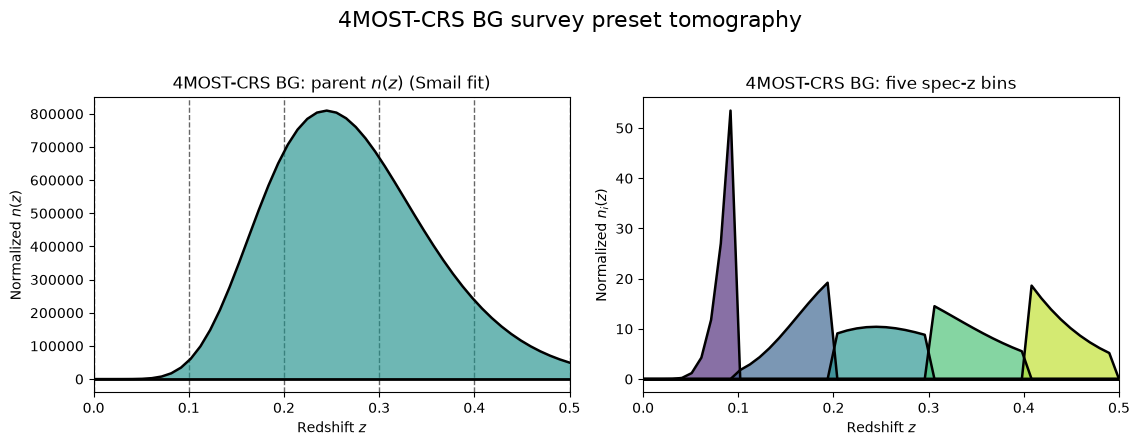

In [15]:
import cmasher as cmr
import matplotlib.pyplot as plt
import numpy as np

from binny import NZTomography


def plot_bins(ax, result, title):
    z = result.z
    bin_dict = result.bins
    keys = sorted(bin_dict.keys())

    colors = cmr.take_cmap_colors(
        "viridis",
        len(keys),
        cmap_range=(0.1, 0.9),
        return_fmt="hex",
    )

    for i, (color, key) in enumerate(zip(colors, keys, strict=True)):
        curve = np.asarray(bin_dict[key], dtype=float)

        ax.fill_between(
            z,
            0.0,
            curve,
            color=color,
            alpha=0.65,
            linewidth=0.0,
            zorder=10 + i,
        )

        ax.plot(
            z,
            curve,
            color="k",
            linewidth=1.8,
            zorder=20 + i,
        )

    ax.plot(z, np.zeros_like(z), color="k", linewidth=2.0, zorder=1000)

    ax.set_title(title)
    ax.set_xlabel("Redshift $z$")


tomo = NZTomography()
result = tomo.build_survey_bins(
    "4most_crs_bg",
    role="source",
    sample="bg",
    include_tomo_metadata=True,
)

edges = result.tomo_meta["bins"]["bin_edges"]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.5),
)

ax = axes[0]
ax.fill_between(
    result.z,
    0.0,
    result.nz,
    color=plt.get_cmap("viridis")(0.5),
    alpha=0.65,
    linewidth=0.0,
    zorder=10,
)
ax.plot(result.z, result.nz, color="k", linewidth=1.8, zorder=20)

for edge in edges:
    ax.axvline(edge, color="k", linestyle="--", linewidth=1.0, alpha=0.6, zorder=5)

ax.plot(result.z, np.zeros_like(result.z), color="k", linewidth=2.0, zorder=1000)
ax.set_title("4MOST-CRS BG: parent $n(z)$ (Smail fit)")
ax.set_xlabel("Redshift $z$")
ax.set_ylabel(r"Normalized $n(z)$")

plot_bins(axes[1], result, "4MOST-CRS BG: five spec-z bins")
axes[1].set_ylabel(r"Normalized $n_i(z)$")

for ax in axes:
    ax.set_xlim(0.0, 0.5)

plt.suptitle("4MOST-CRS BG survey preset tomography", fontsize=16)

plt.tight_layout(rect=(0, 0, 1, 0.95))

In [6]:
result.tomo_meta["bins"]["bin_edges"]

[0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5]

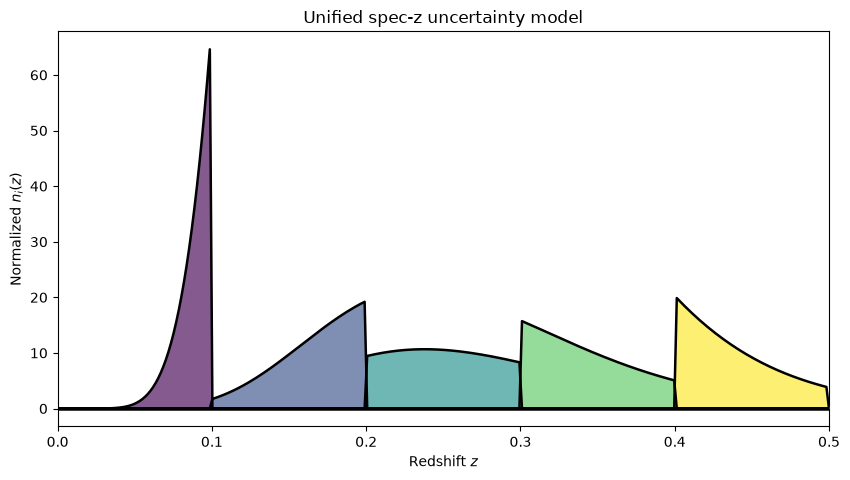

In [7]:


def plot_bins(ax, z, bin_dict, title, xmin=0, xmax=1):
    keys = sorted(bin_dict.keys())
    colors = cmr.take_cmap_colors(
        "viridis",
        len(keys),
        cmap_range=(0.0, 1.0),
        return_fmt="hex",
    )

    for i, (color, key) in enumerate(zip(colors, keys, strict=True)):
        curve = np.asarray(bin_dict[key], dtype=float)
        ax.fill_between(
            z,
            0.0,
            curve,
            color=color,
            alpha=0.65,
            linewidth=0.0,
            zorder=10 + i,
        )
        ax.plot(
            z,
            curve,
            color="k",
            linewidth=1.8,
            zorder=20 + i,
        )

    ax.plot(z, np.zeros_like(z), color="k", linewidth=1.8, zorder=1000)
    ax.set_title(title)
    ax.set_xlabel("Redshift $z$")
    ax.set_ylabel(r"Normalized $n_i(z)$")
    ax.set_xlim(xmin, xmax)

tomo = NZTomography()

z = np.linspace(0.0, 0.5, 300)

nz = NZTomography.nz_model(
    "smail",
    z,
    z0=1.95545983e-02,
    alpha=9.43,
    beta=0.928,
    normalize=True,
)

unified_uncertainty_spec = {
    "kind": "specz",
    "bins": {
        "scheme": "equidistant",
        "n_bins": 5,
    },
    # "uncertainties": {
    #     "completeness": [1.0, 0.97, 0.92, 0.85],
    #     "catastrophic_frac": [0.0, 0.02, 0.05, 0.08],
    #     "leakage_model": "neighbor",
    #     "specz_scatter": [0.008, 0.01, 0.015, 0.052],
    # },
    "normalize_bins": True,
}

unified_result = tomo.build_bins(
    z=z,
    nz=nz,
    tomo_spec=unified_uncertainty_spec,
)

fig, ax = plt.subplots(figsize=(8.6, 4.9))
plot_bins(
    ax,
    z,
    unified_result.bins,
    title="Unified spec-z uncertainty model",
    xmax=0.5
)
plt.tight_layout()

In [18]:
import cmasher as cmr
import matplotlib.pyplot as plt
import numpy as np

from binny import NZTomography


def plot_bins(ax, result, title):
    z = result.z
    bin_dict = result.bins
    keys = sorted(bin_dict.keys())

    colors = cmr.take_cmap_colors(
        "viridis",
        len(keys),
        cmap_range=(0.1, 0.9),
        return_fmt="hex",
    )

    for i, (color, key) in enumerate(zip(colors, keys, strict=True)):
        curve = np.asarray(bin_dict[key], dtype=float)

        ax.fill_between(
            z,
            0.0,
            curve,
            color=color,
            alpha=0.65,
            linewidth=0.0,
            zorder=10 + i,
        )

        ax.plot(
            z,
            curve,
            color="k",
            linewidth=1.8,
            zorder=20 + i,
        )

    ax.plot(z, np.zeros_like(z), color="k", linewidth=2.0, zorder=1000)

    ax.set_title(title)
    ax.set_xlabel("Redshift $z$")


tomo = NZTomography()
# result = tomo.build_survey_bins(
#     "4most_crs_bg",
#     role="source",
#     sample="bg",
#     include_tomo_metadata=True,
# )
result = source
edges = result.tomo_meta["bins"]["bin_edges"]


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11.5, 4.5),
)

ax = axes[0]
ax.fill_between(
    result.z,
    0.0,
    result.nz,
    color=plt.get_cmap("viridis")(0.5),
    alpha=0.65,
    linewidth=0.0,
    zorder=10,
)
ax.plot(result.z, result.nz, color="k", linewidth=1.8, zorder=20)

for edge in edges:
    ax.axvline(edge, color="k", linestyle="--", linewidth=1.0, alpha=0.6, zorder=5)

ax.plot(result.z, np.zeros_like(result.z), color="k", linewidth=2.0, zorder=1000)
ax.set_title("4MOST-CRS BG: parent $n(z)$ (Smail fit)")
ax.set_xlabel("Redshift $z$")
ax.set_ylabel(r"Normalized $n(z)$")

plot_bins(axes[1], result, "4MOST-CRS BG: five spec-z bins")
axes[1].set_ylabel(r"Normalized $n_i(z)$")

for ax in axes:
    ax.set_xlim(0.0, 0.5)

plt.suptitle("4MOST-CRS BG survey preset tomography", fontsize=16)

plt.tight_layout(rect=(0, 0, 1, 0.95))

TypeError: 'NoneType' object is not subscriptable